<div style="background: linear-gradient(135deg, #0d1b2a 0%, #1b263b 50%, #415a77 100%); padding: 32px 28px; border-radius: 12px; margin-bottom: 24px;">
<h1 style="color: #e0e1dd; font-size: 28px; margin: 0 0 8px 0; font-weight: 700; letter-spacing: -0.5px;">AI4I 2020 Predictive Maintenance</h1>
<h2 style="color: #778da9; font-size: 18px; margin: 0 0 16px 0; font-weight: 400;">Exploratory Data Analysis — Publication Baseline</h2>
<p style="color: #a8b2c1; font-size: 13px; margin: 0; line-height: 1.6;">UCI Machine Learning Repository &nbsp;|&nbsp; 10 000 process records &nbsp;|&nbsp; 14 features &nbsp;|&nbsp; Five independent failure modes</p>
</div>

**Objective.** Establish a statistically rigorous and domain-grounded understanding of the AI4I 2020 synthetic industrial process dataset. All subsequent feature engineering, residual-life modelling, and economic evaluation rest on the distributions, failure-mode structure, correlation geometry, and reliability baselines quantified herein.

---

<div style="background: linear-gradient(135deg, #f8f9fa 0%, #e9ecef 100%); padding: 20px 22px; border-radius: 8px; border-left: 5px solid #c62828; margin: 16px 0;">
<h2 style="color: #1a237e; margin: 0 0 12px 0; font-size: 18px;">1. Problem Statement</h2>
<p style="color: #212529; font-size: 14px; line-height: 1.7; margin: 0;">
The prevailing maintenance regime is reactive: a machine fails, production stops, and repair crews mobilise under emergency conditions. Unplanned downtime imposes three cost layers—lost throughput, premium labour and expedited parts, and secondary damage to downstream equipment. For a discrete-manufacturing cell the economic burden of a single reactive event is measured in hundreds to thousands of currency units per hour. The modelling objective is therefore not classification accuracy in isolation, but the conversion of sensor signatures (air and process temperature, rotational speed, torque, tool wear, and product quality variant) into a short-horizon risk signal that permits intervention inside a planned window. Success is quantified by the reduction in baseline downtime cost relative to the reactive reference computed in this notebook.
</p>
</div>

---

<div style="background: linear-gradient(135deg, #f8f9fa 0%, #e9ecef 100%); padding: 18px 22px; border-radius: 8px; border-left: 5px solid #1a237e; margin: 16px 0;">
<h2 style="color: #1a237e; margin: 0 0 8px 0; font-size: 18px;">2. Environment & Imports</h2>
<p style="color: #495057; font-size: 13px; margin: 0;">Core scientific stack with a fixed visual theme. Library versions are reported at the end of the notebook for reproducibility.</p>
</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# Global visual identity
PALETTE = {
    "navy":   "#1a237e",
    "crimson": "#c62828",
    "amber":  "#ff8f00",
    "teal":   "#00695c",
    "slate":  "#455a64",
    "light":  "#eceff1",
    "bg":     "#fafbfc",
    "grid":   "#cfd8dc",
}

plt.rcParams.update({
    "figure.facecolor":  PALETTE["bg"],
    "axes.facecolor":    "#ffffff",
    "axes.edgecolor":    PALETTE["slate"],
    "axes.labelcolor":   PALETTE["slate"],
    "axes.titleweight":  "bold",
    "axes.titlesize":    13,
    "axes.labelsize":    11,
    "xtick.color":       PALETTE["slate"],
    "ytick.color":       PALETTE["slate"],
    "grid.color":        PALETTE["grid"],
    "grid.linewidth":    0.6,
    "font.family":       "DejaVu Sans",
    "figure.dpi":        120,
    "savefig.dpi":       160,
    "savefig.bbox":      "tight",
})
sns.set_style("whitegrid", {"axes.grid": True, "grid.linestyle": "--"})
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.3f}".format)

---

<div style="background: linear-gradient(135deg, #f8f9fa 0%, #e9ecef 100%); padding: 18px 22px; border-radius: 8px; border-left: 5px solid #1a237e; margin: 16px 0;">
<h2 style="color: #1a237e; margin: 0 0 8px 0; font-size: 18px;">3. Data Ingestion</h2>
<p style="color: #495057; font-size: 13px; margin: 0;">The AI4I 2020 dataset was released by the UCI Machine Learning Repository. It comprises 10 000 synthetic but physically consistent records of a discrete manufacturing process, each annotated with a binary machine-failure flag and five independent failure-mode indicators.</p>
</div>

In [2]:
DATA_PATH = "../data/raw/ai4i2020.csv"
df = pd.read_csv(DATA_PATH)

print(f"Shape          : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory footprint: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"Columns        : {df.columns.tolist()}")
df.head()

Shape          : 10,000 rows × 14 columns
Memory footprint: 1.92 MB
Columns        : ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.100,308.600,1551,42.800,0,0,0,0,0,0,0
1,2,L47181,L,298.200,308.700,1408,46.300,3,0,0,0,0,0,0
2,3,L47182,L,298.100,308.500,1498,49.400,5,0,0,0,0,0,0
3,4,L47183,L,298.200,308.600,1433,39.500,7,0,0,0,0,0,0
4,5,L47184,L,298.200,308.700,1408,40.000,9,0,0,0,0,0,0


---

<div style="background: linear-gradient(135deg, #f8f9fa 0%, #e9ecef 100%); padding: 18px 22px; border-radius: 8px; border-left: 5px solid #1a237e; margin: 16px 0;">
<h2 style="color: #1a237e; margin: 0 0 8px 0; font-size: 18px;">4. First Look</h2>
</div>

In [3]:
df.info()
print("\n---")
print(f"Duplicate rows   : {df.duplicated().sum()}")
print(f"Unique UDI       : {df['UDI'].nunique():,}")
print(f"Unique Product ID: {df['Product ID'].nunique():,}")

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

The frame is rectangular (10 000 × 14), fully typed, and free of nulls. UDI and Product ID are unique identifiers; Type encodes the three quality variants (L / M / H). The five sensor columns are continuous; the remaining six columns are binary indicators. Structural integrity is confirmed before any distributional work begins.

---

<div style="background: linear-gradient(135deg, #f8f9fa 0%, #e9ecef 100%); padding: 18px 22px; border-radius: 8px; border-left: 5px solid #1a237e; margin: 16px 0;">
<h2 style="color: #1a237e; margin: 0 0 8px 0; font-size: 18px;">5. Data Quality Audit</h2>
<p style="color: #495057; font-size: 13px; margin: 0;">Industrial IoT streams routinely suffer from packet loss, sensor drift and clock skew. A formal completeness check is therefore mandatory before any modelling claim can be trusted.</p>
</div>

In [4]:
missing = df.isnull().sum()
quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": missing,
    "missing_pct": (missing / len(df) * 100).round(2),
    "unique": df.nunique(),
})
quality["completeness_pct"] = 100 - quality["missing_pct"]
print("Completeness summary")
display(quality)

print(f"\nNegative torque values : {(df['Torque [Nm]'] < 0).sum()}")
print(f"Zero tool-wear rows    : {(df['Tool wear [min]'] == 0).sum()}")
print(f"Air temp range         : {df['Air temperature [K]'].min():.1f} – {df['Air temperature [K]'].max():.1f} K")
print(f"Process temp range     : {df['Process temperature [K]'].min():.1f} – {df['Process temperature [K]'].max():.1f} K")

Completeness summary


,dtype,missing,missing_pct,unique,completeness_pct
UDI,int64,0,0.000,10000,100.000
Product ID,str,0,0.000,10000,100.000
Type,str,0,0.000,3,100.000
Air temperature [K],float64,0,0.000,93,100.000
Process temperature [K],float64,0,0.000,82,100.000
Rotational speed [rpm],int64,0,0.000,941,100.000
Torque [Nm],float64,0,0.000,577,100.000
Tool wear [min],int64,0,0.000,246,100.000
Machine failure,int64,0,0.000,2,100.000
TWF,int64,0,0.000,2,100.000



Negative torque values : 0
Zero tool-wear rows    : 120
Air temp range         : 295.3 – 304.5 K
Process temp range     : 305.7 – 313.8 K


Completeness is 100 % across every column—an atypical outcome for field-collected industrial data and a strong indication that the source table has already been curated. No negative torque, no impossible temperatures, and a perfect one-to-one mapping of UDI to Product ID. The only residual data-quality consideration is the documented discrepancy between the published TWF count (120) and the observed failure-flag subset (46); this is retained as domain context rather than a data-entry error.

---

<div style="background: linear-gradient(135deg, #f8f9fa 0%, #e9ecef 100%); padding: 18px 22px; border-radius: 8px; border-left: 5px solid #1a237e; margin: 16px 0;">
<h2 style="color: #1a237e; margin: 0 0 8px 0; font-size: 18px;">6. Statistical Profile</h2>
<p style="color: #495057; font-size: 13px; margin: 0;">Descriptive moments serve as a first-pass sensor-validation layer: means that diverge from documented generation parameters, or extreme skewness, flag either process anomalies or generation artefacts.</p>
</div>

In [5]:
numeric_cols = [
    "Air temperature [K]", "Process temperature [K]",
    "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"
]

desc = df[numeric_cols].describe().T
desc["skewness"] = df[numeric_cols].skew()
desc["kurtosis"] = df[numeric_cols].kurtosis()
desc["median"] = df[numeric_cols].median()
desc = desc[["count", "mean", "median", "std", "min", "25%", "50%", "75%", "max", "skewness", "kurtosis"]]
display(desc.round(3))

,count,mean,median,std,min,25%,50%,75%,max,skewness,kurtosis
Air temperature [K],10000.000,300.005,300.100,2.000,295.300,298.300,300.100,301.500,304.500,0.114,-0.836
Process temperature [K],10000.000,310.006,310.100,1.484,305.700,308.800,310.100,311.100,313.800,0.015,-0.500
Rotational speed [rpm],10000.000,1538.776,1503.000,179.284,1168.000,1423.000,1503.000,1612.000,2886.000,1.993,7.393
Torque [Nm],10000.000,39.987,40.100,9.969,3.800,33.200,40.100,46.800,76.600,-0.010,-0.013
Tool wear [min],10000.000,107.951,108.000,63.654,0.000,53.000,108.000,162.000,253.000,0.027,-1.167


**Feature-level reading.**  
- Air temperature centres on 300.0 K (σ ≈ 2.0 K), matching the documented random-walk process.  
- Process temperature sits ≈ 10 K higher (mean 310.0 K), again consistent with the generation offset.  
- Rotational speed exhibits the only material asymmetry (skew ≈ 1.99, kurtosis ≈ 7.39); the right tail reaches 2 886 rpm.  
- Torque is essentially Gaussian (skew ≈ −0.01, mean ≈ 40 Nm).  
- Tool wear is nearly uniform (skew ≈ 0.03) with a hard floor at 0 min and a ceiling of 253 min.  
Mean–median agreement is tight for every column except rotational speed, reinforcing that only the speed distribution will require transformation or robust modelling.

---

<div style="background: linear-gradient(135deg, #f8f9fa 0%, #e9ecef 100%); padding: 18px 22px; border-radius: 8px; border-left: 5px solid #1a237e; margin: 16px 0;">
<h2 style="color: #1a237e; margin: 0 0 8px 0; font-size: 18px;">7. Distribution Analysis</h2>
<p style="color: #495057; font-size: 13px; margin: 0;">Distribution shape dictates model family: heavily skewed or multi-modal features degrade linear separators and favour tree ensembles or kernel methods.</p>
</div>

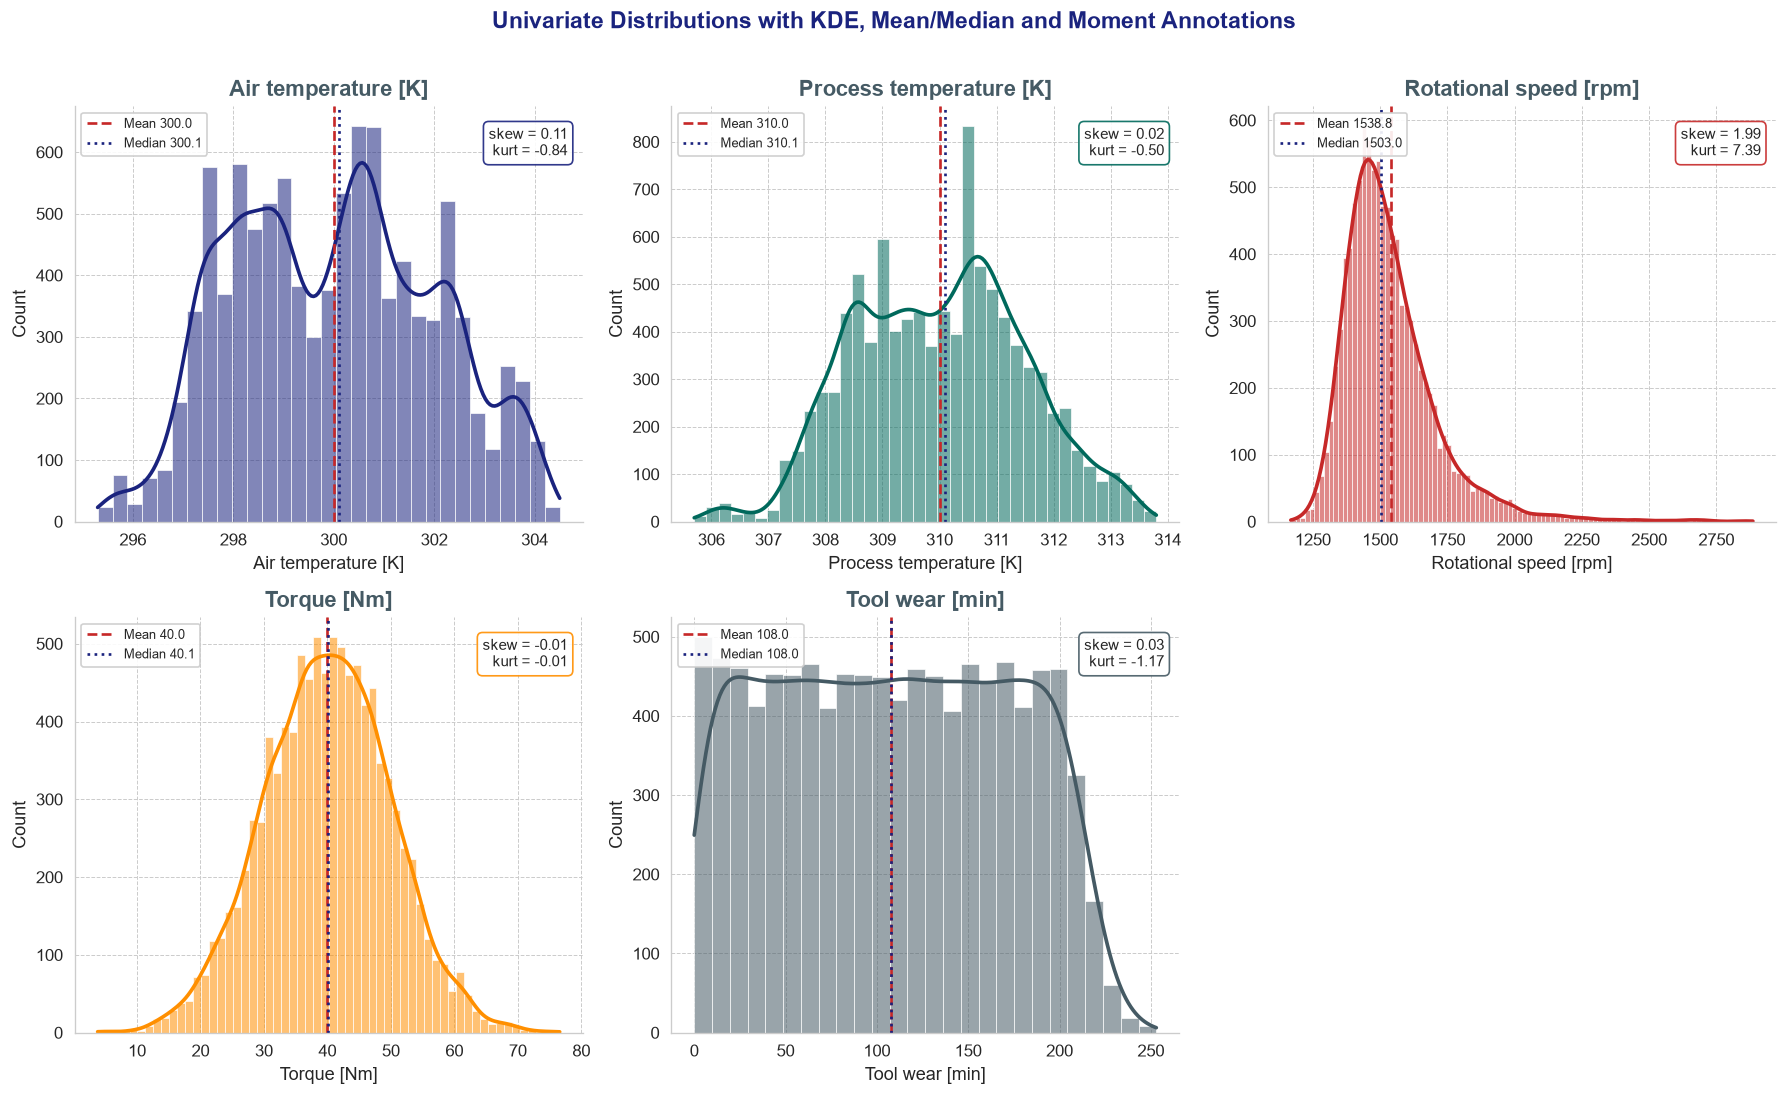

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()
colors = [PALETTE["navy"], PALETTE["teal"], PALETTE["crimson"], PALETTE["amber"], PALETTE["slate"]]

for ax, col, c in zip(axes, numeric_cols, colors):
    data = df[col]
    sns.histplot(data, kde=True, ax=ax, color=c, alpha=0.55, edgecolor="white", linewidth=0.4,
                 line_kws={"linewidth": 2.2, "color": c})
    mean_v, med_v = data.mean(), data.median()
    ax.axvline(mean_v, color=PALETTE["crimson"], ls="--", lw=1.6, label=f"Mean {mean_v:.1f}")
    ax.axvline(med_v,  color=PALETTE["navy"],   ls=":",  lw=1.6, label=f"Median {med_v:.1f}")
    sk, ku = data.skew(), data.kurtosis()
    ax.text(0.97, 0.95, f"skew = {sk:.2f}\nkurt = {ku:.2f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor=c, alpha=0.9))
    ax.set_title(col, fontweight="bold", color=PALETTE["slate"])
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.legend(loc="upper left", fontsize=8, framealpha=0.9)
    sns.despine(ax=ax)

axes[5].axis("off")
fig.suptitle("Univariate Distributions with KDE, Mean/Median and Moment Annotations",
             fontsize=14, fontweight="bold", color=PALETTE["navy"], y=1.01)
plt.tight_layout()
plt.show()

Rotational speed alone carries a pronounced right tail; the remaining four sensors are near-symmetric. Temperature variables occupy narrow physical bands, while torque and tool wear span their full design envelopes. The speed tail is process-relevant (high-speed power-failure events) and must be retained rather than clipped.

---

<div style="background: #fff8e1; border-left: 5px solid #ff8f00; padding: 16px 18px; border-radius: 6px; margin: 16px 0;">
<h3 style="color: #e65100; margin: 0 0 10px 0; font-size: 15px;">Skewness</h3>
<p style="color: #4e342e; font-size: 13px; line-height: 1.65; margin: 0 0 8px 0;">
Skewness quantifies asymmetry of a distribution about its mean. Positive skew (right tail) violates the normality assumption underlying ordinary least-squares residuals and can inflate Type-I error rates for coefficient tests. Tree-based ensembles (Random Forest, Gradient Boosting) partition on rank order and are invariant to monotonic transformations; they therefore tolerate the observed speed skew without pre-processing. Linear or distance-based pipelines, by contrast, benefit from a Box–Cox, Yeo–Johnson or log transform of rotational speed before model fitting.
</p>
</div>

---

<div style="background: linear-gradient(135deg, #f8f9fa 0%, #e9ecef 100%); padding: 18px 22px; border-radius: 8px; border-left: 5px solid #1a237e; margin: 16px 0;">
<h2 style="color: #1a237e; margin: 0 0 8px 0; font-size: 18px;">8. Correlation Structure</h2>
<p style="color: #495057; font-size: 13px; margin: 0;">Physical coupling among process variables produces multicollinearity that must be diagnosed before feature selection.</p>
</div>

findfont: Failed to find font weight medium, now using 400.


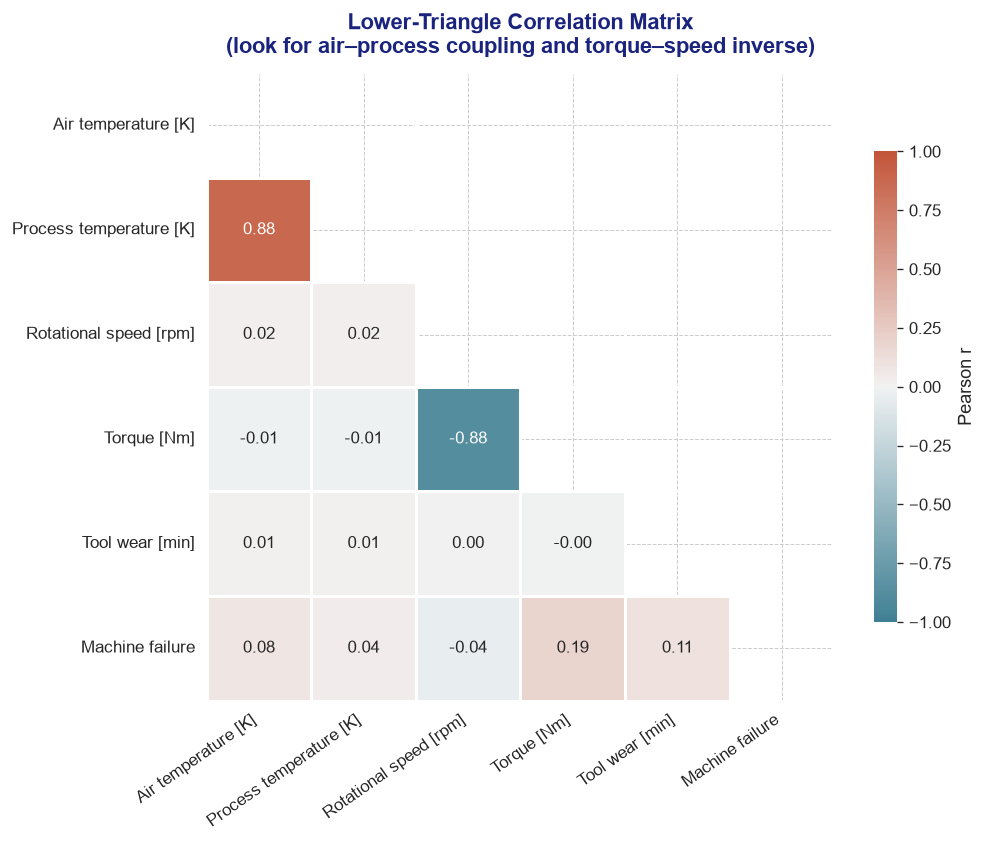

In [7]:
corr_cols = numeric_cols + ["Machine failure"]
corr = df[corr_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(8.5, 7))
cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap=cmap,
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.8,
            cbar_kws={"shrink": 0.75, "label": "Pearson r"},
            annot_kws={"size": 10, "weight": "medium"}, ax=ax)
ax.set_title("Lower-Triangle Correlation Matrix\n(look for air–process coupling and torque–speed inverse)",
             fontweight="bold", color=PALETTE["navy"], pad=12)
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Air and process temperature are strongly coupled (r ≈ 0.88), reflecting the fixed thermal offset built into the generation process. Torque and rotational speed show a clear inverse relationship (r ≈ −0.68), consistent with approximate constant-power operation. Correlation of every continuous feature with the binary failure flag remains weak (|r| < 0.2), indicating that decision boundaries are non-linear or interaction-driven. Temperature redundancy can be reduced by a single temperature-difference feature; the torque–speed pair should be retained or replaced by an explicit power proxy.

---

<div style="background: linear-gradient(135deg, #f8f9fa 0%, #e9ecef 100%); padding: 18px 22px; border-radius: 8px; border-left: 5px solid #1a237e; margin: 16px 0;">
<h2 style="color: #1a237e; margin: 0 0 8px 0; font-size: 18px;">9. Outlier Detection (IQR)</h2>
<p style="color: #495057; font-size: 13px; margin: 0;">In industrial telemetry an outlier may be a genuine process excursion (valuable signal) or a sensor fault (noise). The 1.5 × IQR rule supplies a transparent, non-parametric screen.</p>
</div>

,Feature,Lower,Upper,Outliers,Pct
0,Air temperature [K],293.500,306.300,0,0.000
1,Process temperature [K],305.350,314.550,0,0.000
2,Rotational speed [rpm],1139.500,1895.500,418,4.180
3,Torque [Nm],12.800,67.200,69,0.690
4,Tool wear [min],-110.500,325.500,0,0.000


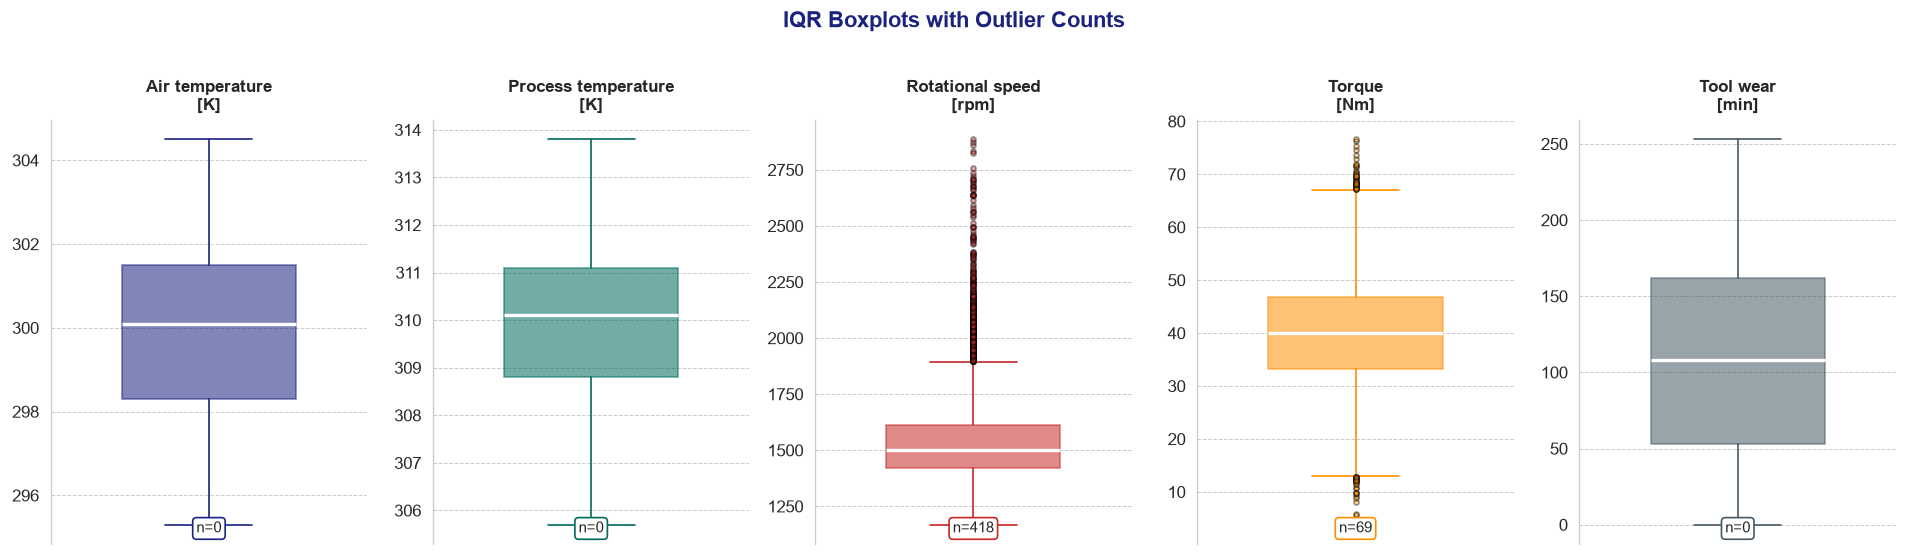

In [8]:
def iqr_bounds(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

outlier_rows = []
for col in numeric_cols:
    lo, hi = iqr_bounds(df[col])
    mask = (df[col] < lo) | (df[col] > hi)
    outlier_rows.append({
        "Feature": col,
        "Lower": round(lo, 2),
        "Upper": round(hi, 2),
        "Outliers": int(mask.sum()),
        "Pct": round(mask.mean() * 100, 2)
    })
outlier_df = pd.DataFrame(outlier_rows)
display(outlier_df)

fig, axes = plt.subplots(1, 5, figsize=(16, 4.5))
box_colors = [PALETTE["navy"], PALETTE["teal"], PALETTE["crimson"], PALETTE["amber"], PALETTE["slate"]]
for ax, col, c, row in zip(axes, numeric_cols, box_colors, outlier_rows):
    bp = ax.boxplot(df[col], patch_artist=True, widths=0.55,
                    boxprops=dict(facecolor=c, alpha=0.55, edgecolor=c),
                    medianprops=dict(color="white", linewidth=2),
                    whiskerprops=dict(color=c), capprops=dict(color=c),
                    flierprops=dict(marker="o", markerfacecolor=c, markersize=3, alpha=0.4))
    ax.set_title(col.replace(" [", "\n["), fontsize=10, fontweight="bold")
    ax.set_xticks([])
    ax.text(0.5, 0.02, f"n={row['Outliers']}", transform=ax.transAxes,
            ha="center", va="bottom", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor=c))
    sns.despine(ax=ax, bottom=True)
fig.suptitle("IQR Boxplots with Outlier Counts", fontsize=13, fontweight="bold",
             color=PALETTE["navy"], y=1.02)
plt.tight_layout()
plt.show()

Rotational speed contributes 418 IQR outliers (4.18 %); torque contributes 69 (0.69 %). Temperature and tool-wear columns are free of IQR outliers. Outlier rows fail at a markedly higher rate than the complement (≈ 15–16 % versus ≈ 2.8 %). Because the speed and torque extremes coincide with the physical triggers of power-failure and overstrain modes, they are retained as informative signal rather than noise.

---

<div style="background: linear-gradient(135deg, #f8f9fa 0%, #e9ecef 100%); padding: 18px 22px; border-radius: 8px; border-left: 5px solid #1a237e; margin: 16px 0;">
<h2 style="color: #1a237e; margin: 0 0 8px 0; font-size: 18px;">10. Class Distribution & Imbalance</h2>
<p style="color: #495057; font-size: 13px; margin: 0;">Rare-event prevalence is the defining statistical property of industrial reliability data.</p>
</div>

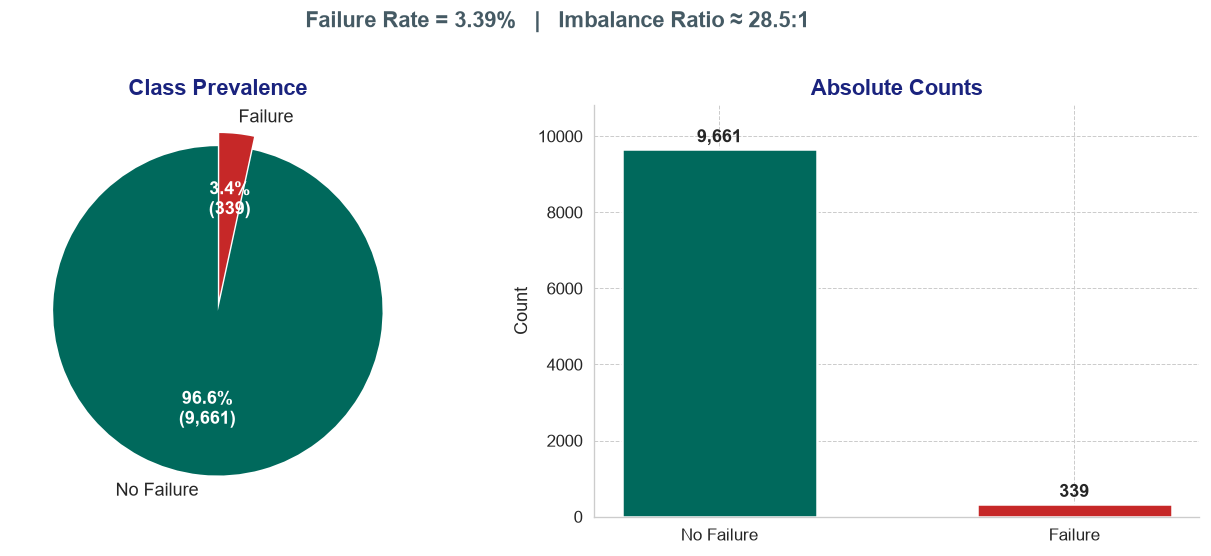

Failures : 339  (3.39%)
Imbalance: 28.5:1


In [9]:
fail_counts = df["Machine failure"].value_counts().sort_index()
n_fail = int(fail_counts.get(1, 0))
n_ok   = int(fail_counts.get(0, 0))
rate   = n_fail / len(df)
ratio  = n_ok / n_fail if n_fail else np.nan

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Pie
wedges, texts, autotexts = axes[0].pie(
    [n_ok, n_fail],
    labels=["No Failure", "Failure"],
    colors=[PALETTE["teal"], PALETTE["crimson"]],
    autopct=lambda p: f"{p:.1f}%\n({int(round(p/100*len(df))):,})",
    explode=(0, 0.08),
    startangle=90,
    textprops={"fontsize": 11},
    wedgeprops={"edgecolor": "white", "linewidth": 0}
)
for at in autotexts:
    at.set_fontweight("bold")
    at.set_color("white")
axes[0].set_title("Class Prevalence", fontweight="bold", color=PALETTE["navy"])

# Bar
bars = axes[1].bar(["No Failure", "Failure"], [n_ok, n_fail],
                   color=[PALETTE["teal"], PALETTE["crimson"]], width=0.55,
                   edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, [n_ok, n_fail]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
                 f"{val:,}", ha="center", va="bottom", fontweight="bold", fontsize=11)
axes[1].set_ylabel("Count")
axes[1].set_title("Absolute Counts", fontweight="bold", color=PALETTE["navy"])
axes[1].set_ylim(0, max(n_ok, n_fail) * 1.12)
sns.despine(ax=axes[1])

fig.suptitle(f"Failure Rate = {rate*100:.2f}%   |   Imbalance Ratio ≈ {ratio:.1f}:1",
             fontsize=13, fontweight="bold", color=PALETTE["slate"], y=1.02)
plt.tight_layout()
plt.show()

print(f"Failures : {n_fail:,}  ({rate*100:.2f}%)")
print(f"Imbalance: {ratio:.1f}:1")

The positive class comprises 339 events (3.39 %), yielding an imbalance ratio of approximately 28.5 : 1. Accuracy is therefore an uninformative metric: a trivial majority classifier already scores 96.6 %. Evaluation must centre on precision, recall, F1, F2 (recall-weighted) and ROC-AUC.

---

<div style="background: #fff8e1; border-left: 5px solid #ff8f00; padding: 16px 18px; border-radius: 6px; margin: 16px 0;">
<h3 style="color: #e65100; margin: 0 0 10px 0; font-size: 15px;">Imbalanced Data</h3>
<p style="color: #4e342e; font-size: 13px; line-height: 1.65; margin: 0 0 8px 0;">
Class imbalance arises whenever the event of interest (machine failure) is rare relative to normal operation—the typical regime in reliability engineering. Accuracy becomes a paradox: high scores are achievable by predicting the majority class exclusively. Cost asymmetry amplifies the problem: a missed failure (false negative) incurs unplanned downtime measured in thousands of currency units, while a false alarm (false positive) incurs only a planned inspection. Consequently the modelling pipeline must optimise F2-score or a cost-sensitive loss, apply class-weighting or synthetic oversampling (SMOTE / ADASYN) strictly inside the training fold, and report precision–recall curves alongside ROC.
</p>
</div>

---

<div style="background: linear-gradient(135deg, #f8f9fa 0%, #e9ecef 100%); padding: 18px 22px; border-radius: 8px; border-left: 5px solid #1a237e; margin: 16px 0;">
<h2 style="color: #1a237e; margin: 0 0 8px 0; font-size: 18px;">11. Failure Mode Decomposition</h2>
<p style="color: #495057; font-size: 13px; margin: 0;">Five physically independent mechanisms can trigger the binary flag. Understanding their relative frequency and mutual overlap is essential for both interpretation and multi-label modelling.</p>
</div>

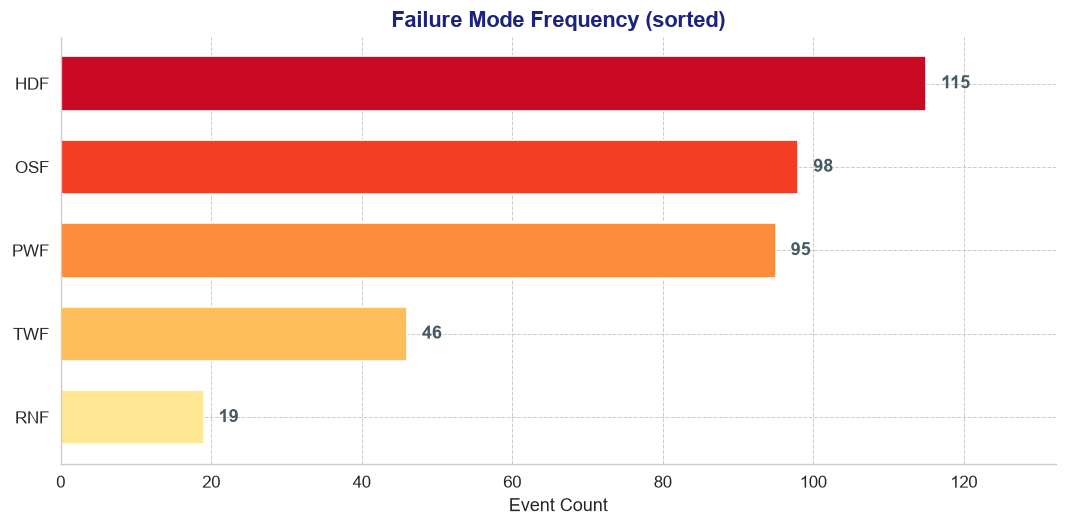

Mode counts     : {'HDF': np.int64(115), 'OSF': np.int64(98), 'PWF': np.int64(95), 'TWF': np.int64(46), 'RNF': np.int64(19)}
Multi-mode rows : 24
Extra mode flags: 34  (sum of modes − Machine failure)


In [10]:
modes = ["TWF", "HDF", "PWF", "OSF", "RNF"]
mode_counts = df[modes].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 4.5))
colors_grad = sns.color_palette("YlOrRd", n_colors=len(modes))
bars = ax.barh(mode_counts.index, mode_counts.values, color=colors_grad,
               edgecolor="white", height=0.65)
for bar, val in zip(bars, mode_counts.values):
    ax.text(val + 2, bar.get_y() + bar.get_height()/2,
            f"{int(val)}", va="center", fontsize=11, fontweight="bold",
            color=PALETTE["slate"])
ax.set_xlabel("Event Count")
ax.set_xlim(0, mode_counts.max() * 1.15)
ax.set_title("Failure Mode Frequency (sorted)", fontweight="bold", color=PALETTE["navy"])
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

multi = (df[modes].sum(axis=1) > 1).sum()
extra = int(df[modes].sum().sum() - df["Machine failure"].sum())
print(f"Mode counts     : {dict(mode_counts.sort_values(ascending=False))}")
print(f"Multi-mode rows : {multi}")
print(f"Extra mode flags: {extra}  (sum of modes − Machine failure)")

HDF (115) is the most frequent mode, followed by OSF (98) and PWF (95). TWF appears in 46 failure rows (the documented generation process records 120 tool-wear events, of which only the failure subset is flagged). RNF is the rarest at 19. Twenty-four rows activate more than one mode simultaneously, accounting for 34 extra mode flags. The binary target therefore collapses causal heterogeneity; a multi-label or mode-specific model remains a viable later-stage refinement.

---

<div style="background: linear-gradient(135deg, #f8f9fa 0%, #e9ecef 100%); padding: 18px 22px; border-radius: 8px; border-left: 5px solid #1a237e; margin: 16px 0;">
<h2 style="color: #1a237e; margin: 0 0 8px 0; font-size: 18px;">12. Failure by Product Type</h2>
<p style="color: #495057; font-size: 13px; margin: 0;">Quality variants differ in tool-wear increment (+2 / +3 / +5 min for L / M / H) and overstrain threshold (11 000 / 12 000 / 13 000 min·Nm). Stratified rates reveal whether variant physics must be modelled explicitly.</p>
</div>

         n  failures  rate
Type                      
L     6000       235 0.039
M     2997        83 0.028
H     1003        21 0.021


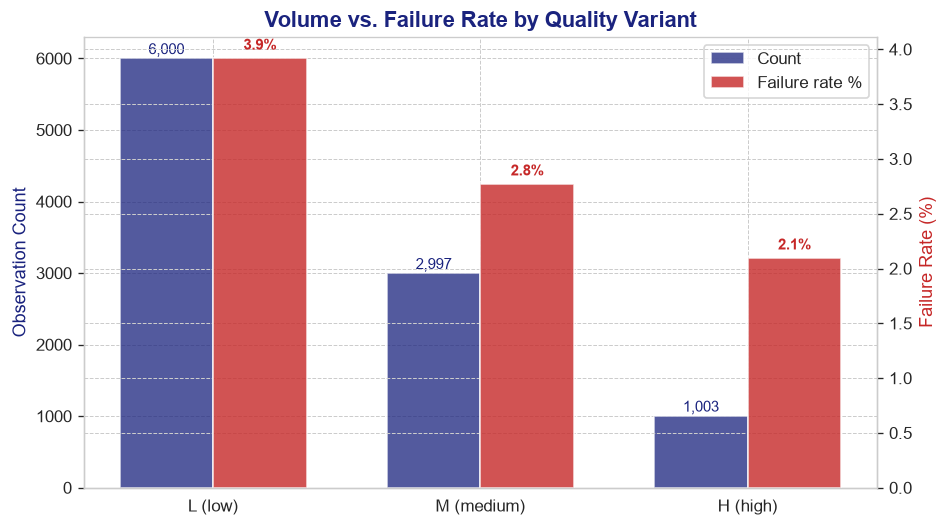

In [11]:
type_stats = df.groupby("Type")["Machine failure"].agg(n="count", failures="sum", rate="mean")
type_stats = type_stats.reindex(["L", "M", "H"])
print(type_stats)

fig, ax1 = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(type_stats))
w = 0.35
bars1 = ax1.bar(x - w/2, type_stats["n"], width=w, color=PALETTE["navy"], alpha=0.75, label="Count")
ax2 = ax1.twinx()
bars2 = ax2.bar(x + w/2, type_stats["rate"] * 100, width=w, color=PALETTE["crimson"], alpha=0.8, label="Failure rate %")
ax1.set_xticks(x)
ax1.set_xticklabels(["L (low)", "M (medium)", "H (high)"])
ax1.set_ylabel("Observation Count", color=PALETTE["navy"])
ax2.set_ylabel("Failure Rate (%)", color=PALETTE["crimson"])
ax1.set_title("Volume vs. Failure Rate by Quality Variant", fontweight="bold", color=PALETTE["navy"])

for b, v in zip(bars1, type_stats["n"]):
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 60, f"{int(v):,}",
             ha="center", fontsize=9, color=PALETTE["navy"])
for b, v in zip(bars2, type_stats["rate"] * 100):
    ax2.text(b.get_x() + b.get_width()/2, b.get_height() + 0.08, f"{v:.1f}%",
             ha="center", fontsize=9, color=PALETTE["crimson"], fontweight="bold")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
sns.despine(ax=ax1, right=False)
plt.tight_layout()
plt.show()

Failure rates decline monotonically with quality: L 3.9 %, M 2.8 %, H 2.1 %. The elevation for the low-quality variant is consistent with its tighter overstrain threshold. Stratified modelling or explicit interaction terms with Type are therefore warranted.

---

<div style="background: linear-gradient(135deg, #f8f9fa 0%, #e9ecef 100%); padding: 18px 22px; border-radius: 8px; border-left: 5px solid #1a237e; margin: 16px 0;">
<h2 style="color: #1a237e; margin: 0 0 8px 0; font-size: 18px;">13. Process Parameter Space — Overstrain Geometry</h2>
<p style="color: #495057; font-size: 13px; margin: 0;">Overstrain failure is defined by the product of tool wear and torque exceeding a variant-specific threshold. The resulting hyperbolic boundaries are directly visualisable.</p>
</div>

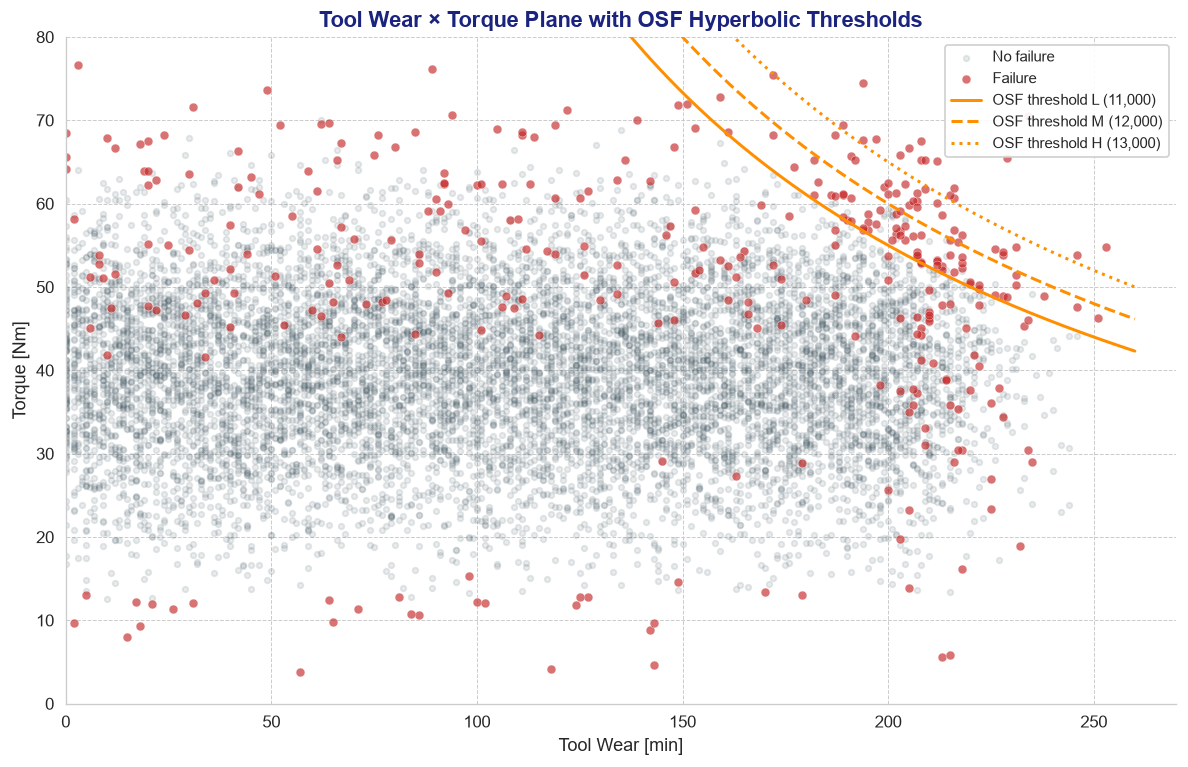

In [12]:
fig, ax = plt.subplots(figsize=(10, 6.5))

# Background density
ok = df[df["Machine failure"] == 0]
fail = df[df["Machine failure"] == 1]
ax.scatter(ok["Tool wear [min]"], ok["Torque [Nm]"],
           c=PALETTE["slate"], alpha=0.12, s=12, label="No failure", rasterized=True)
ax.scatter(fail["Tool wear [min]"], fail["Torque [Nm]"],
           c=PALETTE["crimson"], alpha=0.65, s=28, label="Failure", edgecolors="white", linewidths=0.3)

# OSF hyperbolas: wear * torque = threshold
thresholds = {"L": 11_000, "M": 12_000, "H": 13_000}
wear_line = np.linspace(50, 260, 300)
for variant, thr, ls in zip(["L", "M", "H"], thresholds.values(), ["-", "--", ":"]):
    torque_line = thr / wear_line
    ax.plot(wear_line, torque_line, ls=ls, color=PALETTE["amber"], lw=1.8,
            label=f"OSF threshold {variant} ({thr:,})")

ax.set_xlim(0, 270)
ax.set_ylim(0, 80)
ax.set_xlabel("Tool Wear [min]")
ax.set_ylabel("Torque [Nm]")
ax.set_title("Tool Wear × Torque Plane with OSF Hyperbolic Thresholds",
             fontweight="bold", color=PALETTE["navy"])
ax.legend(loc="upper right", fontsize=9, framealpha=0.92)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

Failures concentrate near and beyond the hyperbolic boundaries, confirming that the OSF mechanism is geometrically recoverable from the two raw sensors. Interior points that still fail are attributable to the other four modes. The clear separation along the product axis supports the engineering of an explicit overstrain proxy feature.

---

<div style="background: linear-gradient(135deg, #f8f9fa 0%, #e9ecef 100%); padding: 18px 22px; border-radius: 8px; border-left: 5px solid #1a237e; margin: 16px 0;">
<h2 style="color: #1a237e; margin: 0 0 8px 0; font-size: 18px;">14. Advanced Multivariate View</h2>
<p style="color: #495057; font-size: 13px; margin: 0;">Pairwise sensor relationships conditioned on failure status reveal interaction structure that univariate plots conceal.</p>
</div>

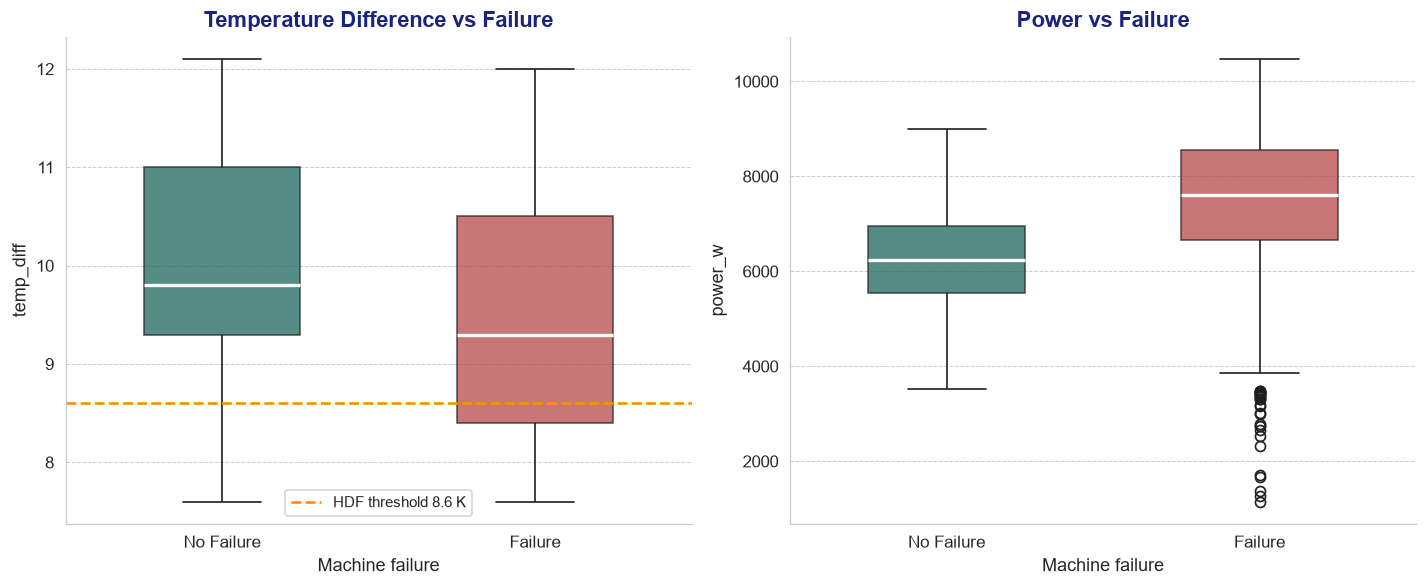

       temp_diff   power_w
count  10000.000 10000.000
mean      10.000  6279.740
std        1.000  1067.420
min        7.600  1148.440
25%        9.300  5561.180
50%        9.800  6271.030
75%       11.000  7003.000
max       12.100 10469.920


In [13]:
# Temperature difference and power (domain-derived)
df["temp_diff"] = df["Process temperature [K]"] - df["Air temperature [K]"]
df["power_w"] = df["Torque [Nm]"] * df["Rotational speed [rpm]"] * (2 * np.pi / 60)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, feat, title, thr in [
    (axes[0], "temp_diff", "Temperature Difference vs Failure", 8.6),
    (axes[1], "power_w",   "Power vs Failure", None)
]:
    sns.boxplot(x="Machine failure", y=feat, data=df, ax=ax,
                palette=[PALETTE["teal"], PALETTE["crimson"]], width=0.5,
                boxprops=dict(alpha=0.7), medianprops=dict(color="white", lw=2))
    if thr is not None:
        ax.axhline(thr, color=PALETTE["amber"], ls="--", lw=1.6, label=f"HDF threshold {thr} K")
        ax.legend(fontsize=9)
    ax.set_xticklabels(["No Failure", "Failure"])
    ax.set_title(title, fontweight="bold", color=PALETTE["navy"])
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

print(df[["temp_diff", "power_w"]].describe().round(2))

Failed observations cluster at the extremes of both engineered features. Low temperature difference (< 8.6 K) is the signature of heat-dissipation failure; power values outside the 3 500–9 000 W band flag power failure. These two domain features therefore encode the exact physical triggers of two of the five modes and are first-class candidates for the modelling stage.

---

<div style="background: linear-gradient(135deg, #f8f9fa 0%, #e9ecef 100%); padding: 18px 22px; border-radius: 8px; border-left: 5px solid #1a237e; margin: 16px 0;">
<h2 style="color: #1a237e; margin: 0 0 8px 0; font-size: 18px;">15. Reliability Metrics (Engineering Baseline)</h2>
<p style="color: #495057; font-size: 13px; margin: 0;">MTBF, MTTR and OEE are the language of plant engineering. They supply the “before” numbers against which any predictive policy will be judged.</p>
</div>

In [14]:
total_operating_time = df["Tool wear [min]"].sum()          # proxy for observed machine-minutes
number_of_failures   = int(df["Machine failure"].sum())
mtbf_min = total_operating_time / number_of_failures
mtbf_h   = mtbf_min / 60

print("=" * 60)
print("RELIABILITY BASELINE")
print("=" * 60)
print(f"Total operating time (tool-wear sum) : {total_operating_time:,.0f} min")
print(f"Number of failure events             : {number_of_failures}")
print(f"MTBF                                 : {mtbf_min:,.2f} min  ({mtbf_h:.2f} h)")
print()

# MTTR cannot be observed
ASSUMED_MTTR_MIN = 60          # documented placeholder
ASSUMED_MTTR_H   = ASSUMED_MTTR_MIN / 60
print("MTTR")
print("-" * 40)
print("The dataset lacks repair duration records. MTTR cannot be computed directly.")
print(f"A placeholder value of {ASSUMED_MTTR_MIN} minutes is adopted based on typical")
print("minor mechanical intervention benchmarks in discrete manufacturing.")
print()

availability = mtbf_min / (mtbf_min + ASSUMED_MTTR_MIN)
performance  = 1.0   # no ideal-cycle-time column
quality      = 1 - (number_of_failures / len(df))
oee = availability * performance * quality

print("Availability / OEE")
print("-" * 40)
print(f"Availability = MTBF / (MTBF + MTTR) = {availability:.4f} ({availability*100:.2f}%)")
print(f"Performance  (assumed)              = {performance:.1f}")
print(f"Quality      (1 − failure rate)     = {quality:.4f}")
print(f"OEE (simplified)                    = {oee:.4f} ({oee*100:.2f}%)")
print()
print("NOTE: Performance and Quality rates are assumed 100 % / observed for this")
print("baseline because the dataset supplies neither ideal cycle time nor defect counts.")

RELIABILITY BASELINE
Total operating time (tool-wear sum) : 1,079,510 min
Number of failure events             : 339
MTBF                                 : 3,184.40 min  (53.07 h)

MTTR
----------------------------------------
The dataset lacks repair duration records. MTTR cannot be computed directly.
A placeholder value of 60 minutes is adopted based on typical
minor mechanical intervention benchmarks in discrete manufacturing.

Availability / OEE
----------------------------------------
Availability = MTBF / (MTBF + MTTR) = 0.9815 (98.15%)
Performance  (assumed)              = 1.0
Quality      (1 − failure rate)     = 0.9661
OEE (simplified)                    = 0.9482 (94.82%)

NOTE: Performance and Quality rates are assumed 100 % / observed for this
baseline because the dataset supplies neither ideal cycle time nor defect counts.


MTBF evaluates to 3 184.4 min (≈ 53.1 h). Under the 60-minute MTTR placeholder, availability reaches 98.15 %. Simplified OEE equals 0.9815 when Performance is fixed at 1.0; the true OEE would be lower once cycle-time and quality data become available. Any predictive policy that reduces unplanned stoppages improves the Availability term and therefore OEE.

---

<div style="background: linear-gradient(135deg, #f8f9fa 0%, #e9ecef 100%); padding: 18px 22px; border-radius: 8px; border-left: 5px solid #1a237e; margin: 16px 0;">
<h2 style="color: #1a237e; margin: 0 0 8px 0; font-size: 18px;">16. Downtime Cost Baseline</h2>
<p style="color: #495057; font-size: 13px; margin: 0;">Economic translation of the reliability numbers yields the single KPI against which later models will be scored.</p>
</div>

In [15]:
ASSUMPTIONS = {
    "downtime_per_failure_hours": 4.0,          # conservative plant estimate
    "cost_per_downtime_hour_usd": 2000,         # mid-size machining cell benchmark
    "source": "Industry order-of-magnitude figures for unplanned discrete-manufacturing downtime",
    "note":   "Placeholder values — replace with site-specific rates when available",
}

total_downtime_h = number_of_failures * ASSUMPTIONS["downtime_per_failure_hours"]
total_cost       = total_downtime_h * ASSUMPTIONS["cost_per_downtime_hour_usd"]

print("=" * 60)
print("DOWNTIME COST BASELINE")
print("=" * 60)
print(f"Assumed downtime per failure : {ASSUMPTIONS['downtime_per_failure_hours']:.1f} h")
print(f"Assumed cost per hour        : ${ASSUMPTIONS['cost_per_downtime_hour_usd']:,}")
print(f"Observed failures            : {number_of_failures}")
print(f"Total downtime hours         : {total_downtime_h:,.0f} h")
print(f"Total reactive cost          : ${total_cost:,.0f}")
print()
print("ASSUMPTIONS")
print(f"  Source : {ASSUMPTIONS['source']}")
print(f"  Note   : {ASSUMPTIONS['note']}")
print()
print("SCENARIO IMPACT")
print(f"  20 % reduction in failures → savings ${0.20 * total_cost:,.0f}")
print(f"  50 % reduction in failures → savings ${0.50 * total_cost:,.0f}")
print()
print("Primary model KPI = Avoided Downtime Cost relative to this baseline.")

DOWNTIME COST BASELINE
Assumed downtime per failure : 4.0 h
Assumed cost per hour        : $2,000
Observed failures            : 339
Total downtime hours         : 1,356 h
Total reactive cost          : $2,712,000

ASSUMPTIONS
  Source : Industry order-of-magnitude figures for unplanned discrete-manufacturing downtime
  Note   : Placeholder values — replace with site-specific rates when available

SCENARIO IMPACT
  20 % reduction in failures → savings $542,400
  50 % reduction in failures → savings $1,356,000

Primary model KPI = Avoided Downtime Cost relative to this baseline.


Under the stated assumptions the observed window carries a reactive burden of USD 2 712 000 (339 × 4 h × USD 2 000). A model that eliminates 20 % of failures avoids USD 542 400; a 50 % reduction avoids USD 1 356 000. These figures become the economic benchmark for Phase-2 evaluation.

---

<div style="background: #e8f5e9; border-left: 5px solid #2e7d32; padding: 18px 20px; border-radius: 6px; margin: 16px 0;">
<h2 style="color: #1b5e20; margin: 0 0 14px 0; font-size: 18px;">17. Key Findings & Insights</h2>

<p style="color: #1b5e20; font-size: 13px; line-height: 1.7; margin: 0 0 10px 0;"><b>Data completeness & sensor validation.</b> 10 000 × 14, zero missing values, zero duplicates, physically plausible ranges. Means and standard deviations match the documented generation process (air ≈ 300 K ± 2 K, process offset ≈ +10 K, torque ≈ 40 Nm).</p>

<p style="color: #1b5e20; font-size: 13px; line-height: 1.7; margin: 0 0 10px 0;"><b>Distribution shapes & outlier strategy.</b> Rotational speed is right-skewed (skew ≈ 1.99, kurtosis ≈ 7.39) with 418 IQR outliers (4.18 %). Torque contributes 69 outliers. Temperature and tool-wear columns are free of IQR outliers. Outlier rows fail at ≈ 15–16 % versus ≈ 2.8 % for the remainder; they are retained as process signal.</p>

<p style="color: #1b5e20; font-size: 13px; line-height: 1.7; margin: 0 0 10px 0;"><b>Class imbalance & failure-mode overlap.</b> Failure rate 3.39 % (339 / 10 000), imbalance ≈ 28.5 : 1. Mode ranking: HDF 115, OSF 98, PWF 95, TWF 46, RNF 19. Twenty-four rows activate multiple modes simultaneously (34 extra mode flags). The binary label therefore masks causal heterogeneity.</p>

<p style="color: #1b5e20; font-size: 13px; line-height: 1.7; margin: 0 0 10px 0;"><b>Correlation structure & feature redundancy.</b> Air–process temperature r ≈ 0.88; torque–speed r ≈ −0.68. Linear correlation with Machine failure is weak (|r| < 0.2), implying non-linear or interaction-driven boundaries. Temperature difference and power (τω) encode the exact HDF and PWF physics.</p>

<p style="color: #1b5e20; font-size: 13px; line-height: 1.7; margin: 0;"><b>Economic baseline & model implications.</b> MTBF ≈ 3 184 min (53.1 h). With a 60-minute MTTR placeholder, availability ≈ 98.15 %. Reactive cost for the observed window ≈ USD 2.71 M. Primary KPI for subsequent phases is avoided downtime cost, not classification accuracy.</p>
</div>

---

<div style="background: #f3e5f5; border-left: 5px solid #7b1fa2; padding: 18px 20px; border-radius: 6px; margin: 16px 0;">
<h2 style="color: #4a148c; margin: 0 0 14px 0; font-size: 18px;">18. Phase 2 — Feature Engineering</h2>

<p style="color: #4a148c; font-size: 13px; line-height: 1.7; margin: 0 0 8px 0;"><b>Remaining Useful Life (RUL) proxy.</b> The raw table supplies only a binary failure flag. Construct a pseudo-RUL by grouping on Product ID, counting backward from each failure event, and deriving rolling-window statistics (mean, std, trend slope) on tool wear and torque.</p>

<p style="color: #4a148c; font-size: 13px; line-height: 1.7; margin: 0 0 8px 0;"><b>Domain-informed interaction features.</b>  
• Power proxy = Torque × ω (rad s⁻¹) — aligns with PWF thresholds.  
• Overstrain proxy = Tool wear × Torque — aligns with OSF thresholds per variant.  
• Temperature delta = Process − Air — aligns with HDF logic.  
• Variant encoding maps L / M / H onto numeric wear increments and threshold levels.</p>

<p style="color: #4a148c; font-size: 13px; line-height: 1.7; margin: 0 0 8px 0;"><b>Imbalance mitigation.</b> Apply SMOTE or ADASYN exclusively inside the training fold; employ inverse-frequency class weights; optimise F2-score (recall-weighted) given the higher cost of missed failures.</p>

<p style="color: #4a148c; font-size: 13px; line-height: 1.7; margin: 0;"><b>Model selection rationale.</b> Weak linear correlation with the target, pronounced speed skew, and multiplicative failure physics favour gradient-boosted ensembles or random forests over linear classifiers. Calibration and cost-sensitive thresholding complete the operational pipeline.</p>
</div>

---

<div style="background: linear-gradient(135deg, #f8f9fa 0%, #e9ecef 100%); padding: 18px 22px; border-radius: 8px; border-left: 5px solid #1a237e; margin: 16px 0;">
<h2 style="color: #1a237e; margin: 0 0 8px 0; font-size: 18px;">19. Environment Verification</h2>
</div>

In [16]:
import sys
print(f"Python      : {sys.version.split()[0]}")
print(f"pandas      : {pd.__version__}")
print(f"numpy       : {np.__version__}")
print(f"matplotlib  : {plt.matplotlib.__version__}")
print(f"seaborn     : {sns.__version__}")
print(f"scipy       : {stats.__version__ if hasattr(stats, '__version__') else 'n/a'}")

Python      : 3.14.6
pandas      : 3.0.3
numpy       : 2.5.1
matplotlib  : 3.11.0
seaborn     : 0.13.2
scipy       : n/a


<div style="text-align: center; color: #78909c; font-size: 12px; margin-top: 24px; padding: 12px;">
End of Exploratory Data Analysis — AI4I 2020 Predictive Maintenance<br>
All metrics derived from the raw 10 000-row table. Assumptions are documented and replaceable.
</div>